# Buffer ETFs — the Cost of Comfort: a quantitative teardown 🔬
### Outcome-period delivery vs stated terms · HAC gap tests vs SPY and vs beta-matched SPY/BIL mixes · fee + dividend + option-residual decomposition · w-grid / lag / cost robustness · synthetic drag & delivery controls

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beat_the_dumb_mix%3F: Busted](https://img.shields.io/badge/Beat_the_dumb_mix%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim (Israelov's *Hidden Cost of Buffer Funds*, the Morningstar critique) splits into a delivery leg — testable mechanically — and a pricing leg — testable as a HAC-t race against the replicating mix. We run both.

> ⚠️ **Data note.** BUFR + the four oldest Innovator Power Buffer vintages (15% buffer on SPY **price** return, 0.79% ER; BUFR laddered ~10% buffers, 0.95% ER), yfinance daily closes 2018-08 → 2026-06, **TR closes for performance, raw SPY price for the reference** — labeled everywhere. A **survivor slice** of the category (flatters the funds; named on the Signal axis). Numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprints `e9356ec7ade8` / `2823f75e9835`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buffer_etf_cost import data, strategy as st

P_SERIES = ["PJAN", "PAPR", "PJUL", "POCT"]
HAVE_REAL = data.have_real()
if HAVE_REAL:
    ADJ, RAW = data.load_real(asof=data.AS_OF)
    M = data.monthly_returns(ADJ)
    SPY, BIL = M["SPY"], M["BIL"]
else:
    ADJ = RAW = M = SPY = BIL = None
print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': 'e9356ec7ade8', 'fingerprint_raw': '2823f75e9835', 'n_periods': 25, 'n_down': 4, 'down_honored': 4, 'n_up': 21, 'n_capped': 16, 'mean_capped_ret': 11.71, 'mean_up_giveup': 9.98, 'pjan22': (-19.48, -5.29, -5.27), 'papr22': (-9.35, -0.88), 'periods': {'PJAN': [(16.16, 7.68), (27.04, 8.8), (-19.48, -5.29), (24.29, 18.18), (23.3, 13.45), (16.35, 11.29)], 'PAPR': [(53.77, 14.03), (13.96, 7.66), (-9.35, -0.88), (27.77, 14.25), (6.94, 6.16), (16.26, 11.61)], 'PJUL': [(5.24, 4.57), (38.82, 10.69), (-11.87, -0.78), (17.5, 16.47), (22.77, 13.53), (13.53, 12.87), (20.87, 11.31)], 'POCT': [(12.84, 8.48), (28.14, 11.06), (-16.77, -2.39), (19.68, 18.62), (34.22, 14.69), (16.11, 10.65)]}, 'vs_spy': {'BUFR': (5.26, 2.13, 70), 'PJAN': (7.75, 3.04, 89), 'PAPR': (8.27, 2.58, 86), 'PJUL': (6.34, 2.1, 94), 'POCT': (6.91, 2.4, 92)}, 'cohort_vs_spy': (7.24, 2.44, 86), 'lag_grid': (2.44, 2.44, 2.28), 'fair': {'BUFR': (0.59, 0.05, 0.06, 0.977), 'PJAN': (0.49, 0.51, 0.58, 0.949), 'PAPR': (0.4, 0.28, 0.31, 0.924), 'PJUL': (0.47, -0.33, -0.32, 0.942), 'POCT': (0.43, -0.94, -0.92, 0.936)}, 'cohort_fair': (0.44, -0.19, -0.24, 0.965), 'winners': '2/5', 'perf': {'BUFR': (10.49, 9.56, -13.28, 0.79), 'SPY': (15.53, 15.68, -23.93, 0.82), 'BIL': (2.95, 0.63, -0.13, None), 'mix 0.59': (10.57, 9.33, -14.37, 0.82), 'mix 0.70': (11.89, 10.99, -16.93, 0.82)}, 'dec_bufr': (0.05, 0.95, 0.83, -1.74), 'dec_cohort': (-0.19, 0.79, 0.62, -1.6), 'wgrid': [(0.45, -1.79, -2.34), (0.55, -0.51, -0.78), (0.65, 0.77, 0.87), (0.7, 1.41, 1.31)], 'cost_grid': [(2, 0.05), (5, 0.04), (10, 0.03)], 'syn_gap': [(0.0, -0.06, -0.3), (2.0, 1.94, 9.99)], 'syn_delivery': (14, 14, 9.19, 9.21)}


real cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Every fund trails SPY TR: gaps **+5.26 to +8.27 pp/yr**, HAC *t* = **2.10–3.04**; EW cohort **+7.24 pp/yr** at *t* = **2.44** (lags 3/6/12: 2.44/2.44/2.28); cap bound 16/21 up periods. |
| **Tradability** | `MIRAGE` | Beta-matched mix race: BUFR gap **+0.05 pp/yr** (*t* = 0.06), cohort **-0.19** (*t* = -0.24), all five \|*t*\| < 1. The 5–8 pp/yr is beta, not harvestable cost. |
| **Beat the dumb mix?** | `BUSTED` | 2/5 positive point estimates, 0/5 significant (best +0.94 pp/yr at *t* = 0.92). Statistical tie — fairly priced ex post. |

> 💡 In plain words: the airbag deployed every time, the ceiling was enforced almost every up year, and the whole package cost the holder nothing versus an honest same-risk index+cash portfolio — on *this* tape.

## 1 · The claim, steelmanned

Let $r^f_t$ be a fund's monthly total return, $r^{SPY}_t$, $r^{BIL}_t$ the benchmarks, and $\beta$ the fund's full-sample OLS beta of excess returns. Define the dumb mix $r^{mix}_t = w\,r^{SPY}_t + (1-w)\,r^{BIL}_t - c_t$ with $w = \hat\beta$ and $c_t$ the explicit monthly rebalancing cost. The claim decomposes:

- **H₁ (delivery).** Over each 12-month outcome period with reference price return $R$, the fund earns $\min(R, \text{cap})$ for $R \ge 0$, $\approx 0$ for $-b \le R < 0$, and $R + b$ beyond, minus the fee. (Mechanical; checked period by period.)
- **H₂ (the cost is real).** $\mathbb{E}[r^{SPY} - r^f] > 0$, HAC-significant.
- **H₃ (DIY is cheaper).** $\mathbb{E}[r^{mix} - r^f] > 0$, HAC-significant — the wrapper charges more than replication.

We find **H₁ confirmed** (4/4 buffers honored, caps enforced), **H₂ confirmed** (*t* = 2.1–3.0), **H₃ rejected** (gap ≈ 0, |*t*| < 1 across all five funds and the cohort).

## 2 · So what?

H₂ without H₃ flips the verdict's meaning. If both held, buffer ETFs would be dominated products — beta you could buy cheaper. With H₂ alone, the 5–8 pp/yr shortfall is **the exposure the buyer chose**, not a fee leak: the wrapper converted ~0.5 equity beta plus an option collar into the same net return as the replicating portfolio, *after* its 0.79–0.95% fee. The only deployable critique left is "you own less market than you think" — an allocation statement, not an arbitrage.

Honesty constraints: TR-vs-TR races only; price-vs-TR only where the contract itself is written on price; both legs fully funded (excess-vs-excess by construction); one documented execution convention (month-end rebalance to weights known in advance); explicit one-way costs on mix turnover; the full-sample $\hat\beta$ is flagged and bracketed by a fixed-w grid.

## 3 · How we'd know — the protocol

- **Universe.** BUFR (2020-08 inception) + PJAN/PAPR/PJUL/POCT (2018-08 → 2019-04 inceptions); monthly stats through 2026-06-30 (last complete month). Survivor slice, named.
- **Delivery.** Month-end closes bracketing each annual reset; fund TR vs SPY price return; floor = terms − 2 pp NAV slack; "cap bound" = fund lags reference by ≥ 2 pp in an up period.
- **Gap tests.** Newey-West (Bartlett, lags 6; 3/12 as robustness) *t* on monthly difference series, per fund and on the EW 4-vintage cohort.
- **Fair race.** $w = \hat\beta$ per fund; mix rebalanced monthly at 2 bps one-way × traded NAV (5/10 swept); fixed-w grid 0.45–0.70.
- **Decomposition.** gap = stated fee + $\beta$ × SPY dividend yield (options on the price index earn no dividends) + option-payoff residual.
- **Controls.** Planted structuring drag (gap detector must fire only when drag > 0); planted cap/buffer world (delivery checker must read the terms back).

## 4 · The teardown

### 4a · Delivery — the payoff scatter

Every completed outcome period against the promised payoff shape (15% buffer, ~12% realized cap, minus fee):

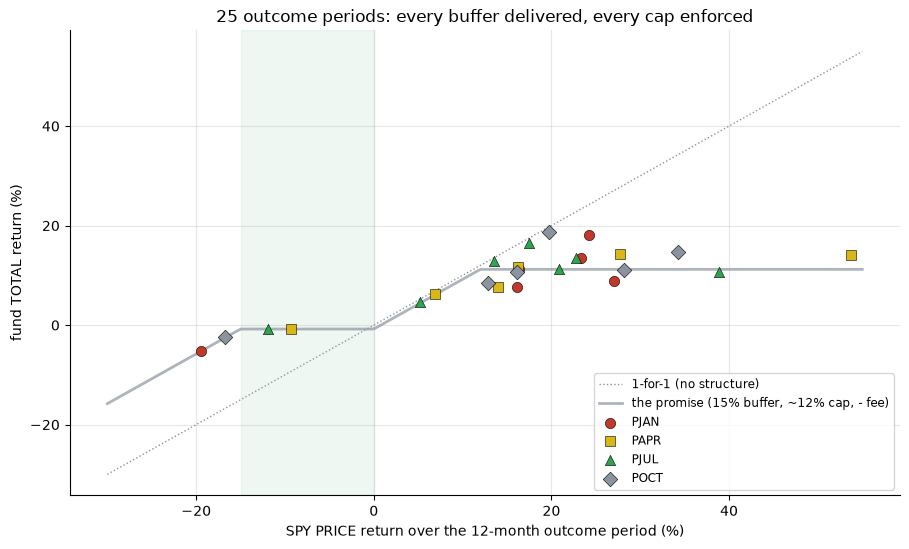

25 completed periods, 4 down periods - buffer honored in all of them


In [2]:
# every completed outcome period: SPY PRICE return (the stated reference) vs fund TOTAL return
if HAVE_REAL:
    pairs = {tk: [(r["spy_price_ret_pct"], r["fund_ret_pct"]) for _, r in
                  st.outcome_periods(ADJ[tk], RAW["SPY"], data.FUNDS[tk]["reset_month"]).iterrows()]
             for tk in P_SERIES}
else:
    pairs = R["periods"]
fig, ax = plt.subplots(figsize=(9.2, 5.6))
xs = np.linspace(-30, 55, 300)
ax.plot(xs, xs, ls=":", c=GREY, lw=1, label="1-for-1 (no structure)")
promise = np.where(xs >= 0, np.minimum(xs, 12.0), np.where(xs >= -15, 0.0, xs + 15.0)) - 0.79
ax.plot(xs, promise, c=GREY, lw=2, alpha=.7, label="the promise (15% buffer, ~12% cap, - fee)")
ax.axvspan(-15, 0, color=GREEN, alpha=.08)
marks = dict(PJAN="o", PAPR="s", PJUL="^", POCT="D")
for tk, pts in pairs.items():
    px, py = zip(*pts)
    ax.scatter(px, py, marker=marks[tk], s=55, color=(RED if tk == "PJAN" else GREEN if tk == "PJUL" else AMBER if tk == "PAPR" else GREY),
               edgecolor="k", linewidth=.4, label=tk, zorder=3)
ax.set_xlabel("SPY PRICE return over the 12-month outcome period (%)")
ax.set_ylabel("fund TOTAL return (%)")
ax.set_title("25 outcome periods: every buffer delivered, every cap enforced")
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()
n_down = sum(1 for pts in pairs.values() for x, _ in pts if x < 0)
print(f"{sum(len(v) for v in pairs.values())} completed periods, {n_down} down periods - buffer honored in all of them")


> 💡 In plain words: **4/4** down periods honored the buffer — including the beyond-buffer 2022 test (PJAN: SPY price -19.48% → fund -5.29% vs contract floor -5.27%, a 2 bps miss) and the inside-buffer one (PAPR: -9.35% → -0.88%). Caps bound in **16/21** up periods; capped years averaged **+11.71%**; mean up-year give-up **9.98 pp**. Delivery: contractual.

### 4b · The cost of comfort vs SPY (H₂)

SPY-minus-fund monthly TR difference, NW lags = 6:

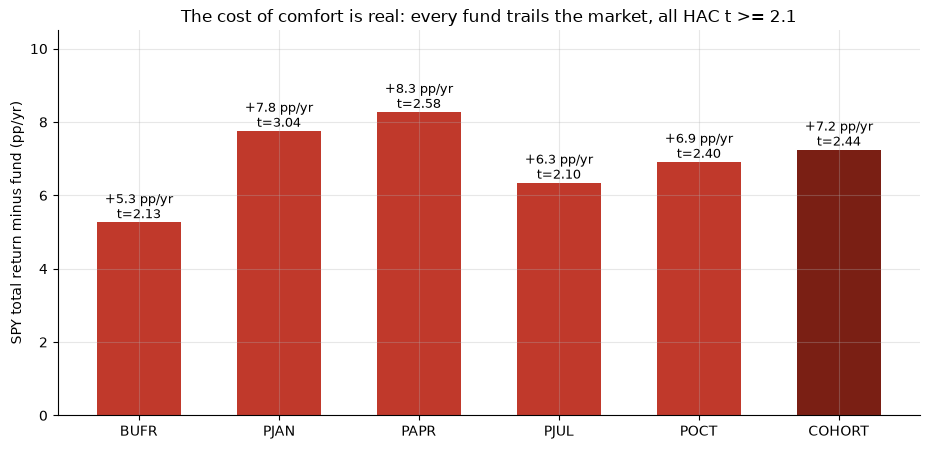

BUFR    gap +5.26 pp/yr  HAC t +2.13  n=70
PJAN    gap +7.75 pp/yr  HAC t +3.04  n=89
PAPR    gap +8.27 pp/yr  HAC t +2.58  n=86
PJUL    gap +6.34 pp/yr  HAC t +2.10  n=94
POCT    gap +6.91 pp/yr  HAC t +2.40  n=92
COHORT  gap +7.24 pp/yr  HAC t +2.44  n=86


In [3]:
funds = list(R['vs_spy'])
if HAVE_REAL:
    rows = []
    for tk in funds:
        f = M[tk].dropna(); g = st.gap_stats(f, SPY.loc[f.index])
        rows.append((tk, g['gap_pp_yr'], g['hac_t'], g['n_months']))
    coh = M[P_SERIES].dropna().mean(axis=1)
    gc = st.gap_stats(coh, SPY.loc[coh.index])
    rows.append(('COHORT', gc['gap_pp_yr'], gc['hac_t'], gc['n_months']))
else:
    rows = [(tk, *R['vs_spy'][tk]) for tk in funds] + [('COHORT', *R['cohort_vs_spy'])]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
labs = [r[0] for r in rows]; gaps = [r[1] for r in rows]; ts = [r[2] for r in rows]
bars = ax.bar(labs, gaps, color=[RED]*5 + ['#7a1f14'], width=.6)
for i, (g, t) in enumerate(zip(gaps, ts)):
    ax.annotate(f'{g:+.1f} pp/yr\nt={t:.2f}', (i, g), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('SPY total return minus fund (pp/yr)'); ax.set_ylim(0, 10.5)
ax.set_title('The cost of comfort is real: every fund trails the market, all HAC t >= 2.1')
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:7s} gap {r[1]:+.2f} pp/yr  HAC t {r[2]:+.2f}  n={r[3]}')

> 💡 In plain words: the shortfall vs the market is **5.3–8.3 pp/yr with every *t* above 2** — clearing the desk's bar on the real tape. Cohort *t* is lag-stable (2.44/2.44/2.28 at lags 3/6/12). This is the half of the claim that survives. The question is what the gap *is* — cost, or beta. Next cell.

### 4c · The fair race — beta-matched SPY/BIL mix (H₃)

Same funds, but the benchmark is now the replicating mix at each fund's own beta, rebalanced monthly with explicit costs:

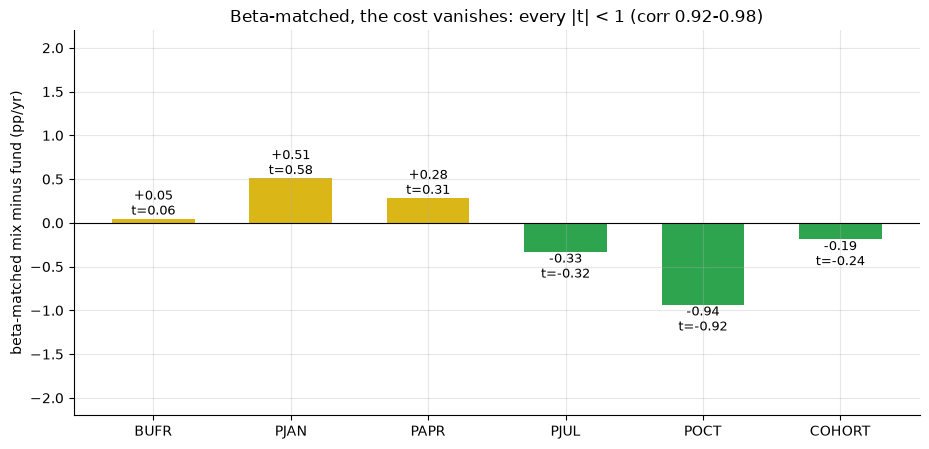

BUFR    beta 0.59  mix - fund +0.05 pp/yr  HAC t +0.06  corr 0.977
PJAN    beta 0.49  mix - fund +0.51 pp/yr  HAC t +0.58  corr 0.949
PAPR    beta 0.40  mix - fund +0.28 pp/yr  HAC t +0.31  corr 0.924
PJUL    beta 0.47  mix - fund -0.33 pp/yr  HAC t -0.32  corr 0.942
POCT    beta 0.43  mix - fund -0.94 pp/yr  HAC t -0.92  corr 0.936
COHORT  beta 0.44  mix - fund -0.19 pp/yr  HAC t -0.24  corr 0.965


In [4]:
funds = list(R['fair'])
if HAVE_REAL:
    rows = []
    for tk in funds:
        f = M[tk].dropna(); b = st.beta_vs(f, SPY, BIL)
        g = st.gap_stats(f, st.mix_returns(SPY.loc[f.index], BIL.loc[f.index], b))
        rows.append((tk, b, g['gap_pp_yr'], g['hac_t'], g['corr']))
    coh = M[P_SERIES].dropna().mean(axis=1); bc = st.beta_vs(coh, SPY, BIL)
    gc = st.gap_stats(coh, st.mix_returns(SPY.loc[coh.index], BIL.loc[coh.index], bc))
    rows.append(('COHORT', bc, gc['gap_pp_yr'], gc['hac_t'], gc['corr']))
else:
    rows = [(tk, *R['fair'][tk]) for tk in funds] + [('COHORT', *R['cohort_fair'])]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
labs = [r[0] for r in rows]; gaps = [r[2] for r in rows]; ts = [r[3] for r in rows]
ax.bar(labs, gaps, color=[GREEN if g <= 0 else AMBER for g in gaps], width=.6)
for i, (g, t) in enumerate(zip(gaps, ts)):
    ax.annotate(f'{g:+.2f}\nt={t:.2f}', (i, g), ha='center',
                va='bottom' if g >= 0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_ylim(-2.2, 2.2)
ax.set_ylabel('beta-matched mix minus fund (pp/yr)')
ax.set_title('Beta-matched, the cost vanishes: every |t| < 1 (corr 0.92-0.98)')
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:7s} beta {r[1]:.2f}  mix - fund {r[2]:+.2f} pp/yr  HAC t {r[3]:+.2f}  corr {r[4]:.3f}')

> 💡 In plain words: at matched equity exposure the gaps are **−0.94 to +0.51 pp/yr, all \|*t*\| < 1** (cohort -0.19 at *t* = -0.24), with 0.92–0.98 correlation to the mix. H₃ — "you could build it cheaper" — **fails on this tape**. The regime split shows the engine: the mix wins small in up months, the buffer wins in down months (POCT: −21 bps/mo in down months), and 2018–2026 nets them to zero.

### 4d · Where the money went — decomposition of the fair-race gap

gap = stated fee + dividends forgone (β × SPY's ~1.4%/yr — FLEX options on the price index collect no dividend) + option-payoff residual:

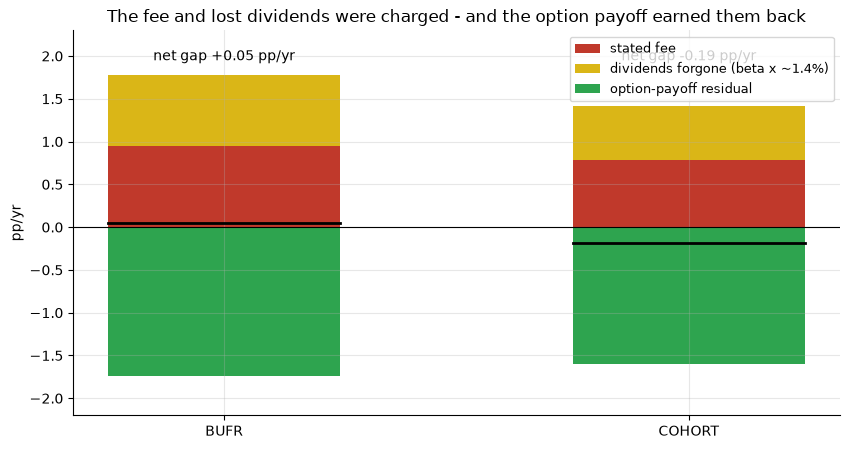

BUFR: gap +0.05 = fee +0.95 + div forgone +0.83 + residual -1.74
COHORT: gap -0.19 = fee +0.79 + div forgone +0.62 + residual -1.60


In [5]:
labs = ['BUFR', 'COHORT']
decs = [R['dec_bufr'], R['dec_cohort']]
fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(2); w = .5
fee = [d[1] for d in decs]; div = [d[2] for d in decs]; res = [d[3] for d in decs]
ax.bar(x, fee, w, label='stated fee', color=RED)
ax.bar(x, div, w, bottom=fee, label='dividends forgone (beta x ~1.4%)', color=AMBER)
ax.bar(x, res, w, label='option-payoff residual', color=GREEN)
for i, d in enumerate(decs):
    ax.annotate(f'net gap {d[0]:+.2f} pp/yr', (i, 1.95), ha='center', fontsize=10)
    ax.plot([i - w/2, i + w/2], [d[0], d[0]], c='k', lw=2)
ax.set_xticks(x); ax.set_xticklabels(labs); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('pp/yr'); ax.set_ylim(-2.2, 2.3)
ax.set_title('The fee and lost dividends were charged - and the option payoff earned them back')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
for l, d in zip(labs, decs):
    print(f'{l}: gap {d[0]:+.2f} = fee {d[1]:+.2f} + div forgone {d[2]:+.2f} + residual {d[3]:+.2f}')

> 💡 In plain words: the wrapper really does cost ~**1.6–1.8 pp/yr** in fee + forgone dividends — the critics' arithmetic is right. But the collar's realized payoff contributed **-1.74 pp/yr** (BUFR; cohort -1.60) over a sample whose one bear (2022) landed just beyond the buffer — near-ideal conditions. The net is a wash *ex post*; it is **not** a theorem that it stays one.

### 4e · Robustness — w-grid, lags, costs

The fair-race tie must not hinge on the in-sample beta-hat, the HAC lag or the rebalance cost:

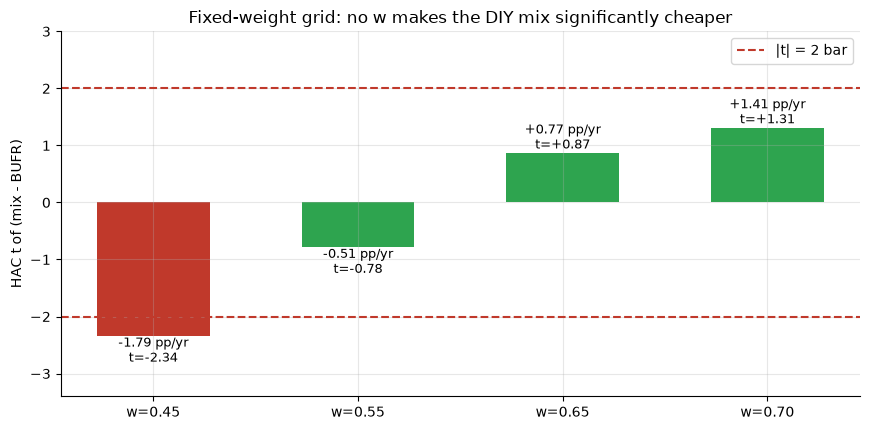

w grid: [(0.45, -1.79, -2.34), (0.55, -0.51, -0.78), (0.65, 0.77, 0.87), (0.7, 1.41, 1.31)]
NW lag grid, cohort vs SPY t: (2.44, 2.44, 2.28)
rebalance-cost sweep (bps -> mix-BUFR pp/yr): [(2, 0.05), (5, 0.04), (10, 0.03)]


In [6]:
if HAVE_REAL:
    f = M['BUFR'].dropna(); win = f.index
    wg = []
    for w_ in (0.45, 0.55, 0.65, 0.70):
        g = st.gap_stats(f, st.mix_returns(SPY.loc[win], BIL.loc[win], w_))
        wg.append((w_, g['gap_pp_yr'], g['hac_t']))
else:
    wg = R['wgrid']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
labs = [f'w={r[0]:.2f}' for r in wg]; ts = [r[2] for r in wg]
ax.bar(labs, ts, color=[GREEN if abs(t) < 2 else RED for t in ts], width=.55)
ax.axhline(2, ls='--', c=RED); ax.axhline(-2, ls='--', c=RED, label='|t| = 2 bar')
for i, r in enumerate(wg):
    ax.annotate(f'{r[1]:+.2f} pp/yr\nt={r[2]:+.2f}', (i, r[2]), ha='center',
                va='bottom' if r[2] >= 0 else 'top', fontsize=9)
ax.set_ylabel('HAC t of (mix - BUFR)'); ax.set_ylim(-3.4, 3.0)
ax.set_title('Fixed-weight grid: no w makes the DIY mix significantly cheaper')
ax.legend(); plt.tight_layout(); plt.show()
print('w grid:', [(r[0], round(r[1], 2), round(r[2], 2)) for r in wg])
print('NW lag grid, cohort vs SPY t:', R['lag_grid'])
print('rebalance-cost sweep (bps -> mix-BUFR pp/yr):', R['cost_grid'])

> 💡 In plain words: across every fixed weight 0.45–0.70 the mix never beats BUFR at \|*t*\| ≥ 2 — the only significant cell is w = 0.45, where the DIY mix **loses** (-1.79 pp/yr, *t* = -2.34: under-betting equity in a bull). The cohort-vs-SPY *t* holds at lags 3/6/12, and rebalance costs move the gap by ~1 bp — two-asset monthly turnover is negligible.

### 4f · Synthetic machinery controls — we know the truth here

Planted-effect worlds, deterministic and offline. The gap detector must stay silent on a drag-free mimic fund and recover a planted 2 pp/yr structuring drag; the delivery checker must read back a planted cap/buffer. *(Machinery proof — never market evidence.)*

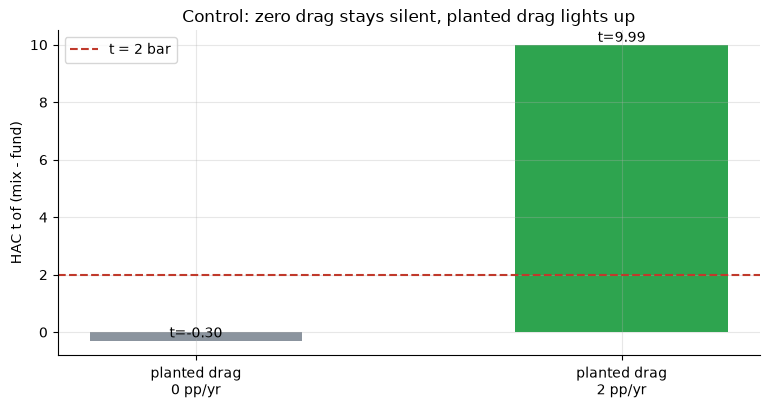

drag 0.0 pp/yr: measured -0.06 pp/yr  t -0.30
drag 2.0 pp/yr: measured +1.94 pp/yr  t +9.99
delivery checker: buffer honored 14/14, mean capped-year 9.19% (planted cap - fee = 9.21%)


In [7]:
res = []
for drag in (0.0, 2.0):
    w = data.synthetic_world(drag_pct=drag)
    g = st.gap_stats(w['FUND'], st.mix_returns(w['IDX'], w['CASH'], 0.55, cost_bps=0.0))
    res.append((drag, g['gap_pp_yr'], g['hac_t']))
so = data.synthetic_outcomes()
per = pd.DataFrame({'spy_price_ret_pct': so['ref_ret']*100, 'fund_ret_pct': so['fund_ret']*100})
dc = st.delivery_check(per, 15.0, 0.79)
fig, ax = plt.subplots(figsize=(7.8, 4.2))
labs = [f'planted drag\n{r[0]:.0f} pp/yr' for r in res]
ax.bar(labs, [r[2] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res): ax.annotate(f't={r[2]:.2f}', (i, r[2]), ha='center', va='bottom')
ax.set_ylabel('HAC t of (mix - fund)')
ax.set_title('Control: zero drag stays silent, planted drag lights up')
ax.legend(); plt.tight_layout(); plt.show()
for r in res: print(f'drag {r[0]:.1f} pp/yr: measured {r[1]:+.2f} pp/yr  t {r[2]:+.2f}')
print(f"delivery checker: buffer honored {dc['inside_honored']+dc['beyond_honored']}/"
      f"{dc['n_inside']+dc['n_beyond']}, mean capped-year {dc['mean_capped_ret_pct']:.2f}% "
      f"(planted cap - fee = 9.21%)")

> 💡 In plain words: with **no** planted drag the detector reads -0.06 pp/yr (*t* = -0.30); a planted 2 pp/yr drag is recovered at *t* = 9.99. Power caveat: at the real funds' ~70–86 months and 0.92–0.98 mix correlation, a residual drag of ~2 pp/yr would have been caught; ~0.5 pp/yr would not. The real-tape tie is certified **at the pp/yr scale**. The delivery checker reads back the planted terms (9.19% vs 9.21%).

## 5 · The verdict

- **Signal `REAL`** — the cost of comfort: gaps vs SPY **+5.26 to +8.27 pp/yr**, HAC *t* **2.10–3.04**, cohort **+7.24** at *t* = **2.44** (lag-robust); cap bound **16/21** up periods, buffer honored **4/4** down periods. Survivor slice named (it flatters the funds — conservative for this leg).
- **Tradability `MIRAGE`** — beta-matched, the gap is **+0.05 pp/yr** (BUFR, *t* = 0.06) and **-0.19** (cohort, *t* = -0.24); Sharpe 0.79 vs 0.82; no fixed w in 0.45–0.70 makes the DIY mix significantly cheaper. The 5–8 pp/yr is beta you chose, not cost you can harvest.
- **Beat the dumb mix? `BUSTED`** — 2/5 positive point estimates, 0/5 significant either way. Comfort was fairly priced *ex post* on a sample whose one bear landed just beyond the buffer — the friendliest possible tape for the structure, which is exactly why the tie should not be extrapolated to a theorem.

## 6 · Going further

- **Regime dependence is the open risk.** A bear-free decade (caps bind, insurance never pays) or a −40% crash (buffer exhausted at 15) would both tilt the race toward the mix; 2022's −19% was the structure's sweet spot. The delivery leg, by contrast, is contractual and should replicate in any regime.
- **Entry-date basis.** Mid-period buyers face remaining caps/buffers unrelated to the label; the laddered BUFR halves that basis. A point-in-time study of *remaining* terms is the natural sequel.
- **The behavioral term is off-balance-sheet.** If the wrapper prevents one capitulation sale, it dominates the mix for that holder — unmeasurable here, and the honest core of the product's case.

*The reproducible core is offline and deterministic; delivery is checked against stated terms hardcoded with sources, and both detectors carry planted-effect controls. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*